# DSCI 552 - Homework 2

**Name:** Ruturaj Mohalkar  
**USC ID:** 6930537443

## Imports

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# 1. Combined Cycle Power Plant Data Set

## 1(a) Download the data

The data set was downloaded from the UCI Machine Learning Repository and saved as `data/CCPP/Folds5x2_pp.xlsx`. The five sheets are shuffled copies of the same data, so Sheet 1 is used.

In [2]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
predictors = ['AT', 'V', 'AP', 'RH']
response = 'PE'

print('Missing values per column:', df.isna().sum().to_dict())
df.head()

Missing values per column: {'AT': 0, 'V': 0, 'AP': 0, 'RH': 0, 'PE': 0}


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) Exploring the data

### 1(b)i. Number of rows and columns

In [3]:
print('Rows:', df.shape[0], '| Columns:', df.shape[1])
print('Columns:', list(df.columns))

Rows: 9568 | Columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


**Answer 1(b)i:** The data set has **9568 rows** and **5 columns**.

Each **row** is one hourly average measurement of the power plant operating at full load, collected over six years (2006-2011), so there are 9568 such hours.

Each **column** is a variable:

| Column | Meaning | Units |
|---|---|---|
| AT | Ambient temperature | °C |
| V | Exhaust vacuum | cm Hg |
| AP | Ambient pressure | millibar |
| RH | Relative humidity | % |
| PE | Net hourly electrical energy output (the response) | MW |

The first four columns are the predictors and PE is the dependent variable.

### 1(b)ii. Pairwise scatterplots

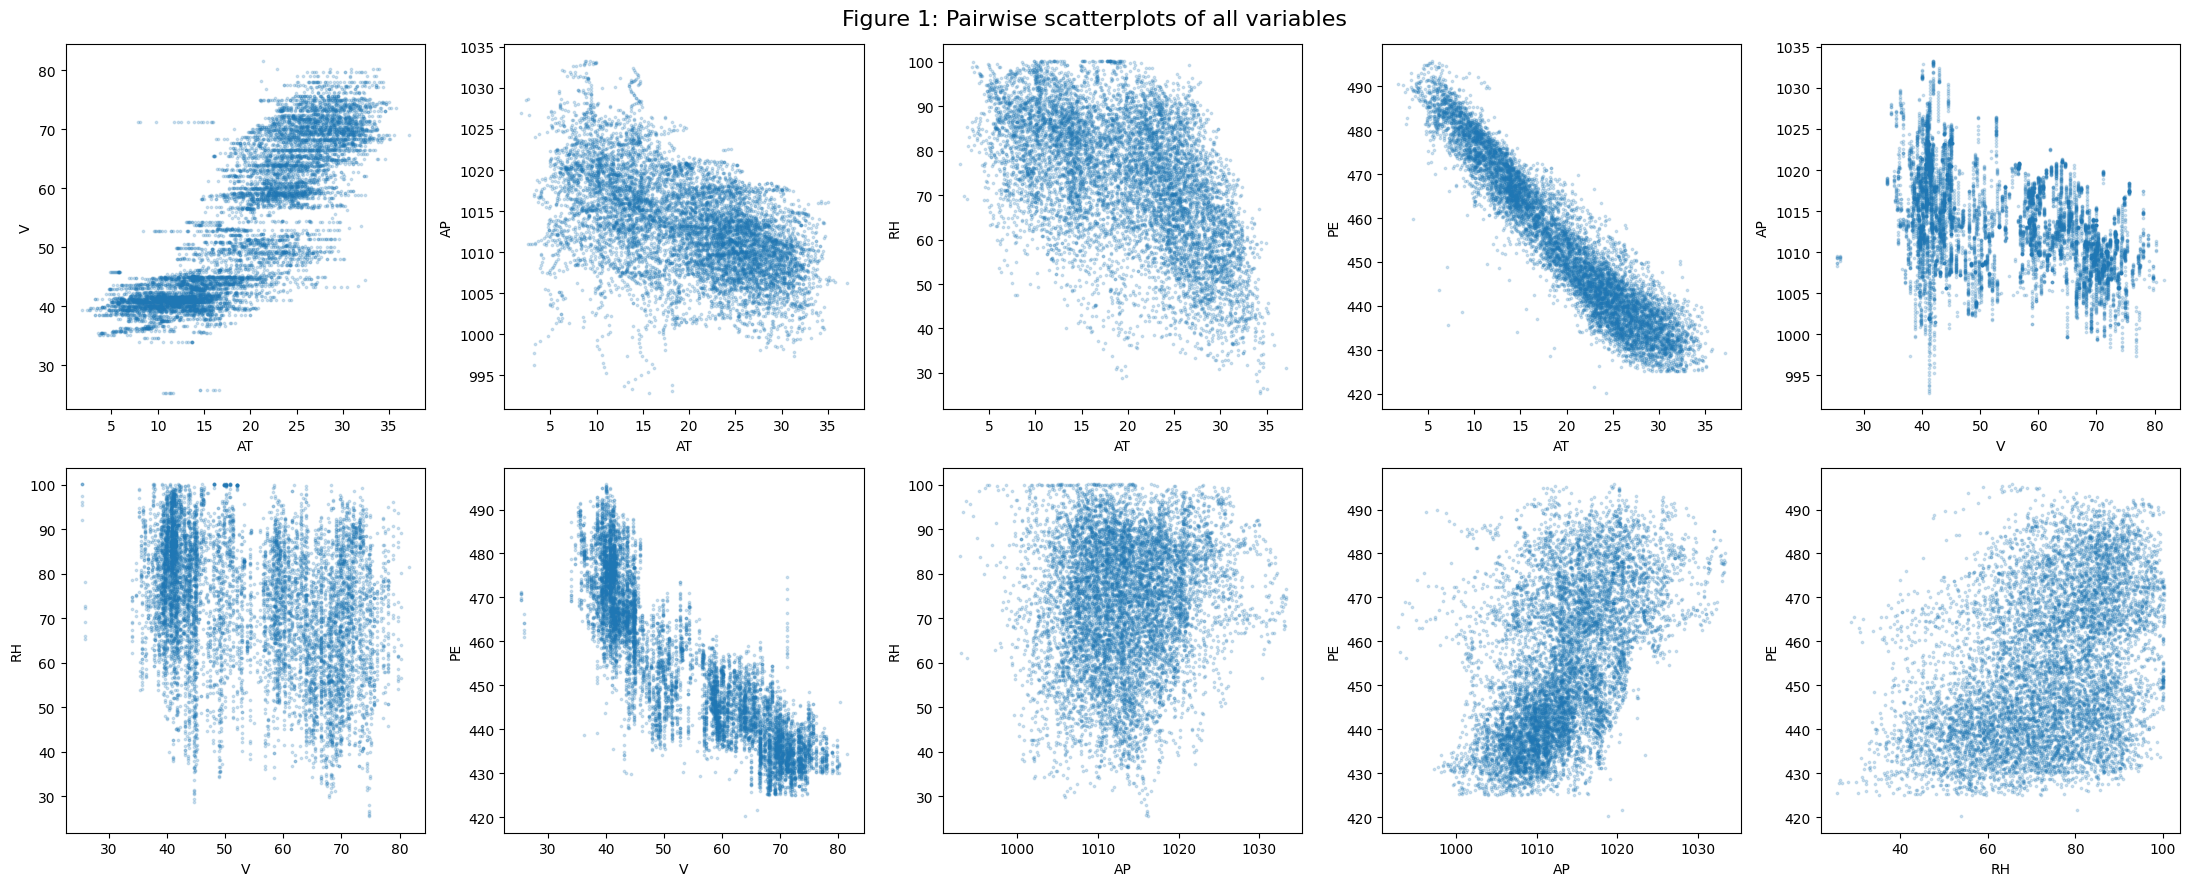

Correlation matrix:


,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [4]:
pairs = list(combinations(df.columns, 2))
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, (x, y) in zip(axes.ravel(), pairs):
    ax.scatter(df[x], df[y], s=3, alpha=0.2, color='tab:blue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
fig.suptitle('Figure 1: Pairwise scatterplots of all variables', fontsize=16)
fig.tight_layout()
plt.show()

print('Correlation matrix:')
df.corr().round(3)

**Answer 1(b)ii:** The scatterplots and the correlation matrix show:

- **PE falls steeply and almost linearly as AT rises** (r = −0.948). Temperature is by far the strongest predictor of energy output, and the cloud around the trend is narrow.
- **PE also falls as V rises** (r = −0.870), but the V plots show banded, almost discrete vertical stripes and the relationship bends slightly, so it is less clean than AT.
- **AP and RH have weaker, positive associations with PE** (r = 0.518 and r = 0.390) with wide, diffuse clouds, so on their own they explain little of the variation.
- **The predictors are themselves correlated**, most strongly AT with V (r = 0.844), then AT with RH (r = −0.543) and AT with AP (r = −0.508). This multicollinearity matters later: it is why the simple and multiple regression coefficients disagree in 1(e).
- Physically this is what one expects. The plant is less efficient in hot, humid, low-pressure air, and high exhaust vacuum accompanies high ambient temperature.

### 1(b)iii. Summary statistics

In [5]:
summary = pd.DataFrame({
    'mean': df.mean(),
    'median': df.median(),
    'min': df.min(),
    'max': df.max(),
    'range': df.max() - df.min(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
})
summary['IQR'] = summary['Q3'] - summary['Q1']
summary.round(3)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


## 1(c) Simple linear regression for each predictor

In [6]:
simple_models = {p: smf.ols(f'{response} ~ {p}', data=df).fit() for p in predictors}

simple_table = pd.DataFrame([{
    'predictor': p,
    'intercept': m.params['Intercept'],
    'slope': m.params[p],
    'std err': m.bse[p],
    't': m.tvalues[p],
    'p-value': m.pvalues[p],
    'R-squared': m.rsquared,
} for p, m in simple_models.items()]).set_index('predictor')
simple_table

,intercept,slope,std err,t,p-value,R-squared
predictor,,,,,,
AT,497.034120,-2.171320,0.007443,-291.715195,0.0,0.898948
V,517.801526,-1.168135,0.006776,-172.401540,0.0,0.756518
AP,-1055.260989,1.489872,0.025126,59.296232,0.0,0.268769
RH,420.961766,0.455650,0.011006,41.398730,0.0,0.151939


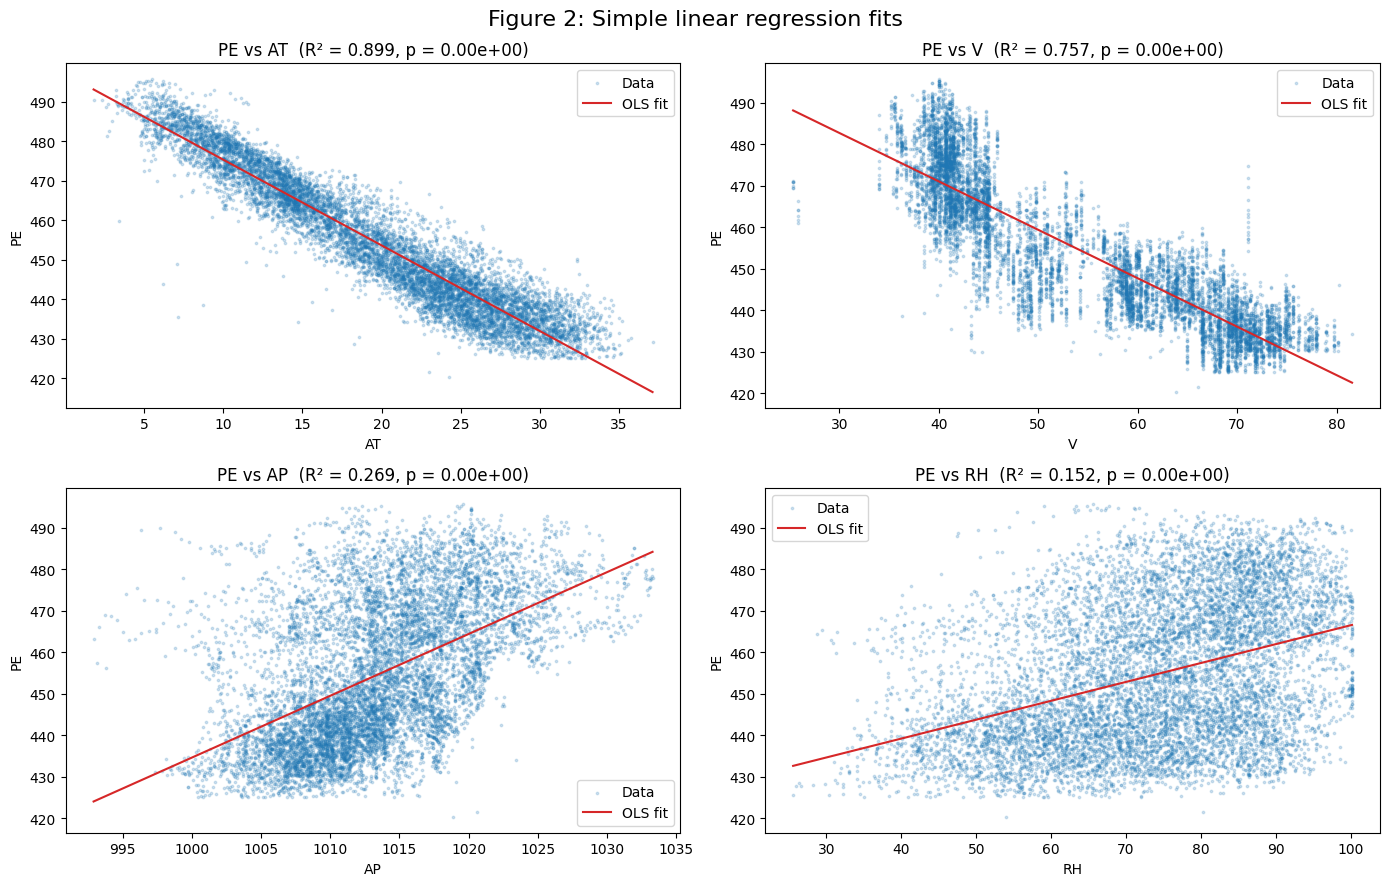

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, p in zip(axes.ravel(), predictors):
    ax.scatter(df[p], df[response], s=3, alpha=0.2, color='tab:blue', label='Data')
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    m = simple_models[p]
    ax.plot(xs, m.params['Intercept'] + m.params[p] * xs, color='tab:red', label='OLS fit')
    ax.set_xlabel(p)
    ax.set_ylabel(response)
    ax.set_title(f'{response} vs {p}  (R² = {m.rsquared:.3f}, p = {m.pvalues[p]:.2e})')
    ax.legend()
fig.suptitle('Figure 2: Simple linear regression fits', fontsize=16)
fig.tight_layout()
plt.show()

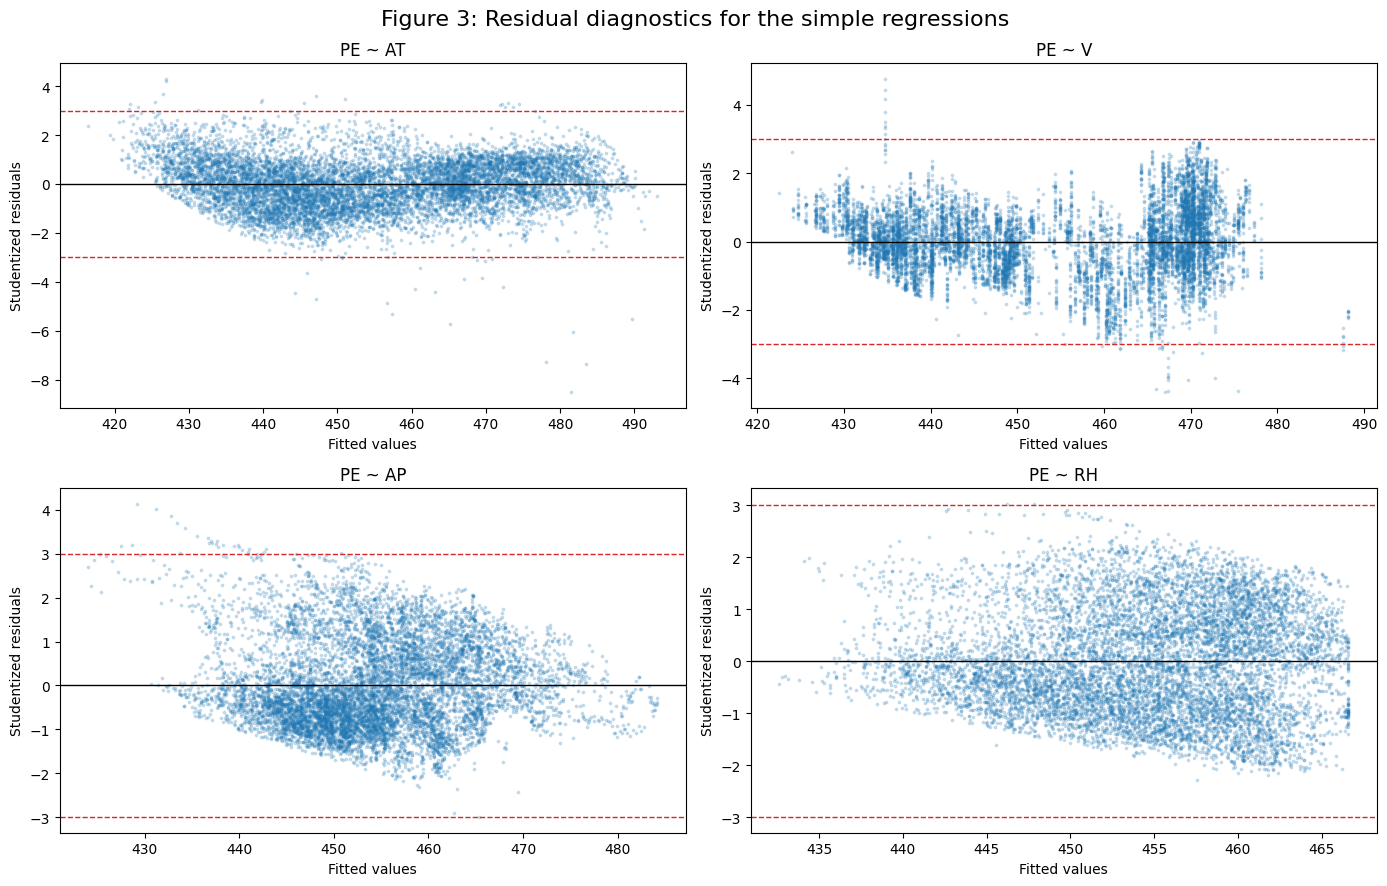

,|studentized residual| > 3,share of data,max Cook's distance
predictor,,,
AT,42,0.44%,0.014325
V,33,0.34%,0.003243
AP,30,0.31%,0.008152
RH,2,0.02%,0.002059


In [8]:
# Outlier diagnostics: studentized residuals and Cook's distance
outlier_rows = []
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, p in zip(axes.ravel(), predictors):
    m = simple_models[p]
    influence = m.get_influence()
    student = influence.resid_studentized_external
    cooks = influence.cooks_distance[0]
    extreme = np.abs(student) > 3
    outlier_rows.append({
        'predictor': p,
        '|studentized residual| > 3': int(extreme.sum()),
        'share of data': f'{extreme.mean():.2%}',
        "max Cook's distance": cooks.max(),
    })
    ax.scatter(m.fittedvalues, student, s=3, alpha=0.2, color='tab:blue')
    ax.axhline(0, color='black', lw=1)
    for line in (-3, 3):
        ax.axhline(line, color='tab:red', ls='--', lw=1)
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Studentized residuals')
    ax.set_title(f'{response} ~ {p}')
fig.suptitle('Figure 3: Residual diagnostics for the simple regressions', fontsize=16)
fig.tight_layout()
plt.show()

pd.DataFrame(outlier_rows).set_index('predictor')

**Answer 1(c):** A simple regression of PE on each predictor gives

| Predictor | Slope | t | p-value | R² |
|---|---|---|---|---|
| AT | −2.171 | −291.7 | ≈ 0 | 0.899 |
| V | −1.168 | −172.4 | ≈ 0 | 0.757 |
| AP | 1.490 | 59.3 | ≈ 0 | 0.269 |
| RH | 0.456 | 41.4 | ≈ 0 | 0.152 |

**In every one of the four models the association is statistically significant**: all p-values are below machine precision (reported as 0.000), far under 0.05, and every |t| exceeds 41. With n = 9568 even a weak association is detected, so the more informative comparison is R²: AT alone explains 89.9% of the variation in PE, V 75.7%, while AP (26.9%) and RH (15.2%) explain much less. Figure 2 backs this up, the AT and V clouds hug their fitted lines while the AP and RH clouds are diffuse.

**Outliers:** Figure 3 and the table above show only 42, 33, 30 and 2 observations with |studentized residual| > 3 for AT, V, AP and RH, which is 0.44% of the data or less, close to what a normal error distribution produces by chance. The largest Cook's distance in any of the four models is 0.014, nowhere near the usual threshold of 1, so no single point has meaningful influence on the fits. **I would not remove any observations.** They are plausible operating hours rather than recording errors, and with n = 9568 they cannot move the estimates. The residual plots do show curvature and a funnel shape for AT and V, which is a sign that the model form is wrong, not that the points are bad, and this is addressed in 1(f).

## 1(d) Multiple regression with all predictors

In [9]:
full_model = smf.ols(f'{response} ~ ' + ' + '.join(predictors), data=df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:14:09   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Answer 1(d):** The fitted model is

PE = 454.61 − 1.978·AT − 0.234·V + 0.062·AP − 0.158·RH

with R² = 0.929 (adjusted R² = 0.929) and F = 3.11 × 10⁴ on (4, 9563) degrees of freedom, p < 0.001, so the model as a whole is highly significant and explains 92.9% of the variation in PE.

**We can reject H₀: βⱼ = 0 for all four predictors — AT, V, AP and RH.** Every p-value is below 0.001 (|t| = 129.3, 32.1, 6.6 and 37.9 respectively), with AP the weakest of the four. Holding the others fixed, each additional °C of ambient temperature costs about 1.98 MW of output, each extra cm Hg of exhaust vacuum 0.23 MW, and each extra percentage point of relative humidity 0.16 MW, while a 1 millibar rise in ambient pressure adds about 0.06 MW.

The summary also notes a condition number of 2.13 × 10⁵. That is driven by the raw scale of AP (around 1013) rather than by severe multicollinearity, and the centered models used from 1(f) onwards bring it down to a few hundred.

## 1(e) Simple vs multiple regression coefficients

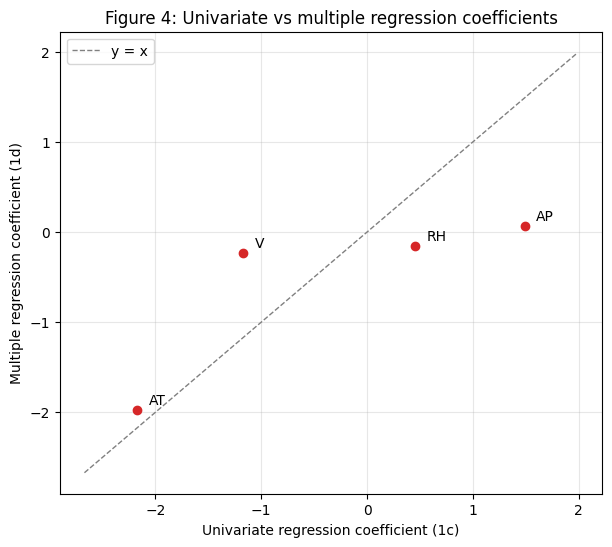

,simple,multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


In [10]:
coef_compare = pd.DataFrame({
    'simple': [simple_models[p].params[p] for p in predictors],
    'multiple': [full_model.params[p] for p in predictors],
}, index=predictors)

plt.figure(figsize=(7, 6))
plt.scatter(coef_compare['simple'], coef_compare['multiple'], color='tab:red', zorder=3)
for p, row in coef_compare.iterrows():
    plt.annotate(p, (row['simple'], row['multiple']), textcoords='offset points', xytext=(8, 4))
lims = [coef_compare.to_numpy().min() - 0.5, coef_compare.to_numpy().max() + 0.5]
plt.plot(lims, lims, ls='--', color='gray', lw=1, label='y = x')
plt.xlabel('Univariate regression coefficient (1c)')
plt.ylabel('Multiple regression coefficient (1d)')
plt.title('Figure 4: Univariate vs multiple regression coefficients')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

coef_compare

**Answer 1(e):** The coefficients differ substantially, and in Figure 4 only AT sits near the y = x line.

| Predictor | Simple (1c) | Multiple (1d) |
|---|---|---|
| AT | −2.171 | −1.978 |
| V | −1.168 | −0.234 |
| AP | 1.490 | 0.062 |
| RH | 0.456 | −0.158 |

- **AT barely changes** (−2.17 → −1.98). It is the dominant predictor, so little of its effect is explained away by the others.
- **V and AP shrink sharply towards zero** (−1.17 → −0.23 and 1.49 → 0.06). Most of what they appeared to explain alone was really temperature acting through them, since V and AP are correlated with AT (r = 0.844 and −0.508).
- **RH changes sign**, from +0.456 alone to −0.158 in the multiple model. On its own, humid hours tend to be cool hours (r(AT, RH) = −0.543), so RH picks up the temperature effect and looks beneficial. Once AT is held fixed, extra humidity in fact lowers output.

This is the standard consequence of correlated predictors: a simple regression coefficient measures the total association, including everything the predictor is correlated with, while a multiple regression coefficient measures the effect with the other predictors held fixed. The two agree only when the predictors are uncorrelated, which they clearly are not here. RH is the sharpest warning against reading the univariate fits causally.

## 1(f) Nonlinear association: cubic fit for each predictor

For each predictor X the model Y = β₀ + β₁X + β₂X² + β₃X³ + ε is fitted. The predictors are centered first, so that the quadratic and cubic terms are not almost perfectly collinear with the linear term (centering shifts the intercept only, the fit is unchanged).

In [11]:
centered = df.copy()
centered[predictors] = df[predictors] - df[predictors].mean()

cubic_rows = []
for p in predictors:
    m = smf.ols(f'{response} ~ {p} + I({p} ** 2) + I({p} ** 3)', data=centered).fit()
    cubic_rows.append({
        'predictor': p,
        'p(linear)': m.pvalues[p],
        'p(quadratic)': m.pvalues[f'I({p} ** 2)'],
        'p(cubic)': m.pvalues[f'I({p} ** 3)'],
        'R-squared': m.rsquared,
        'R-squared (linear only)': simple_models[p].rsquared,
    })

pd.DataFrame(cubic_rows).set_index('predictor')

,p(linear),p(quadratic),p(cubic),R-squared,R-squared (linear only)
predictor,,,,,
AT,0.000000e+00,3.311808e-231,3.652185e-110,0.911883,0.898948
V,0.000000e+00,8.977010e-131,1.373489e-02,0.775022,0.756518
AP,0.000000e+00,2.192722e-46,2.123338e-67,0.297543,0.268769
RH,9.648727e-152,1.013949e-01,1.440279e-05,0.153743,0.151939


**Answer 1(f): Yes, there is clear evidence of nonlinear association.** Fitting Y = β₀ + β₁X + β₂X² + β₃X³ + ε for each predictor gives

| Predictor | p(X²) | p(X³) | R² cubic | R² linear |
|---|---|---|---|---|
| AT | 3.3 × 10⁻²³¹ | 3.7 × 10⁻¹¹⁰ | 0.912 | 0.899 |
| V | 9.0 × 10⁻¹³¹ | 0.014 | 0.775 | 0.757 |
| AP | 2.2 × 10⁻⁴⁶ | 2.1 × 10⁻⁶⁷ | 0.298 | 0.269 |
| RH | 0.101 | 1.4 × 10⁻⁵ | 0.154 | 0.152 |

- **AT, V and AP** have overwhelmingly significant quadratic terms, and AT and AP significant cubic terms as well. The curvature is real, not sampling noise.
- **V** has a strong quadratic term; its cubic term is significant at the 0.05 level (p = 0.014) but only marginally.
- **RH** is the weakest case: its quadratic term is not significant (p = 0.101) while its cubic term is (p = 1.4 × 10⁻⁵), so the departure from linearity is present but mild.

The gains in R² are modest (AT 0.899 → 0.912, AP 0.269 → 0.298, RH 0.152 → 0.154), which is the honest reading: the relationships are close to linear with a real but small amount of curvature, and with n = 9568 even small curvature is detected with tiny p-values. This matches the bowed residual patterns for AT and V in Figure 3.

## 1(g) Pairwise interaction terms

In [12]:
interaction_model = smf.ols(f'{response} ~ (' + ' + '.join(predictors) + ') ** 2', data=centered).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:14:09   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.6946      0.075   6074.393      0.0

In [13]:
interaction_terms = [t for t in interaction_model.params.index if ':' in t]
pd.DataFrame({
    'coefficient': interaction_model.params[interaction_terms],
    'p-value': interaction_model.pvalues[interaction_terms],
    'significant at 0.05': interaction_model.pvalues[interaction_terms] < 0.05,
})

,coefficient,p-value,significant at 0.05
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


**Answer 1(g): Yes, four of the six pairwise interactions are statistically significant.**

| Interaction | Coefficient | p-value | Significant at 0.05 |
|---|---|---|---|
| AT:V | 0.0210 | 3.3 × 10⁻¹¹⁷ | Yes |
| AT:RH | −0.0052 | 1.2 × 10⁻¹⁰ | Yes |
| V:AP | 0.0068 | 2.9 × 10⁻⁷ | Yes |
| AP:RH | −0.0016 | 0.034 | Yes |
| V:RH | 0.0008 | 0.086 | No |
| AT:AP | 0.0018 | 0.452 | No |

**AT:V is by far the strongest**: the penalty from high exhaust vacuum depends on temperature, so the two effects are not additive. AT:RH and V:AP are also strongly significant, and AP:RH is only marginal (p = 0.034, which would not survive a correction for testing six terms). AT:AP and V:RH give no evidence of interaction.

Adding the interactions raises R² from 0.929 to 0.936, a real but modest improvement, so most of the structure in the data is still captured by the additive linear model.

## 1(h) Improving the model on a 70/30 split

Model A uses all four predictors linearly. Model B starts from all pairwise interactions plus quadratic terms and drops insignificant variables by p-value, one at a time (backward elimination at α = 0.05). A main effect is never dropped while an interaction or quadratic term containing it is still in the model, so the model stays hierarchically well formed. Predictors are centered to keep the higher-order terms from being collinear with the linear ones.

In [14]:
train_df, test_df = train_test_split(centered, test_size=0.3, random_state=RANDOM_STATE)
print('Train:', train_df.shape[0], 'rows | Test:', test_df.shape[0], 'rows')


def train_test_mse(model, train, test):
    """MSE of a fitted statsmodels model on the training and test data."""
    return (mean_squared_error(train[response], model.predict(train)),
            mean_squared_error(test[response], model.predict(test)))

Train: 6697 rows | Test: 2871 rows


In [15]:
model_a = smf.ols(f'{response} ~ ' + ' + '.join(predictors), data=train_df).fit()
mse_a = train_test_mse(model_a, train_df, test_df)
print(f'Model A (all predictors, linear): train MSE = {mse_a[0]:.3f}, test MSE = {mse_a[1]:.3f}')

Model A (all predictors, linear): train MSE = 20.581, test MSE = 21.240


In [16]:
def contains_main_effect(term, main):
    """True if `term` is a higher-order term built on the main effect `main`."""
    return term != main and (main in term.split(':') or term == f'I({main} ** 2)')


def backward_eliminate(terms, data, alpha=0.05):
    """Drop the least significant removable term until every p-value is below alpha."""
    terms, dropped = list(terms), []
    while True:
        model = smf.ols(f'{response} ~ ' + ' + '.join(terms), data=data).fit()
        removable = [t for t in terms
                     if not any(contains_main_effect(other, t) for other in terms)]
        pvals = model.pvalues[removable]
        if pvals.empty or pvals.max() <= alpha:
            return model, terms, dropped
        worst = pvals.idxmax()
        dropped.append({'term': worst, 'p-value': pvals.max()})
        terms.remove(worst)


all_terms = predictors + [f'{a}:{b}' for a, b in combinations(predictors, 2)] + \
            [f'I({p} ** 2)' for p in predictors]
model_b, kept_terms, dropped_terms = backward_eliminate(all_terms, train_df)

print('Started with', len(all_terms), 'terms, kept', len(kept_terms))
print('Kept:', ', '.join(kept_terms))
pd.DataFrame(dropped_terms)

Started with 14 terms, kept 11
Kept: AT, V, AP, RH, AT:V, AT:AP, AT:RH, AP:RH, I(AT ** 2), I(AP ** 2), I(RH ** 2)


,term,p-value
0,V:RH,0.867382
1,I(V ** 2),0.607733
2,V:AP,0.357826


In [17]:
mse_b = train_test_mse(model_b, train_df, test_df)
print(f'Model B (interactions + quadratics, pruned): train MSE = {mse_b[0]:.3f}, test MSE = {mse_b[1]:.3f}')

pd.DataFrame({'train MSE': [mse_a[0], mse_b[0]], 'test MSE': [mse_a[1], mse_b[1]]},
             index=['Model A: all predictors, linear',
                    'Model B: interactions + quadratics, pruned'])

Model B (interactions + quadratics, pruned): train MSE = 17.891, test MSE = 18.660


,train MSE,test MSE
"Model A: all predictors, linear",20.580840,21.239857
"Model B: interactions + quadratics, pruned",17.890843,18.660040


**Answer 1(h): Yes, the model improves.** On a random 70/30 split (6697 train, 2871 test rows):

| Model | Train MSE | Test MSE |
|---|---|---|
| A: all four predictors, linear | 20.581 | 21.240 |
| B: pairwise interactions + quadratics, pruned | 17.891 | 18.660 |

Backward elimination started from 14 terms and dropped three, in order: **V:RH** (p = 0.867), **V²** (p = 0.608) and **V:AP** (p = 0.358), leaving 11 terms — the four main effects, the interactions AT:V, AT:AP, AT:RH and AP:RH, and the quadratics AT², AP² and RH². Main effects were protected from removal while a higher-order term containing them remained, which is why AT:AP survives even though it was insignificant in 1(g): once quadratic terms are present, its p-value changes.

Model B cuts test MSE by 12.1% (21.240 → 18.660). For both models the test MSE is only slightly above the train MSE (18.66 vs 17.89), so the pruned model is not overfitting; the extra terms capture the genuine curvature and interaction found in 1(f) and 1(g).

## 1(i) KNN regression

KNN regression is run for k ∈ {1, ..., 100} on the same 70/30 split, once with the raw features and once with normalized features (standardized using the training mean and standard deviation only, so that no test information leaks into the scaling).

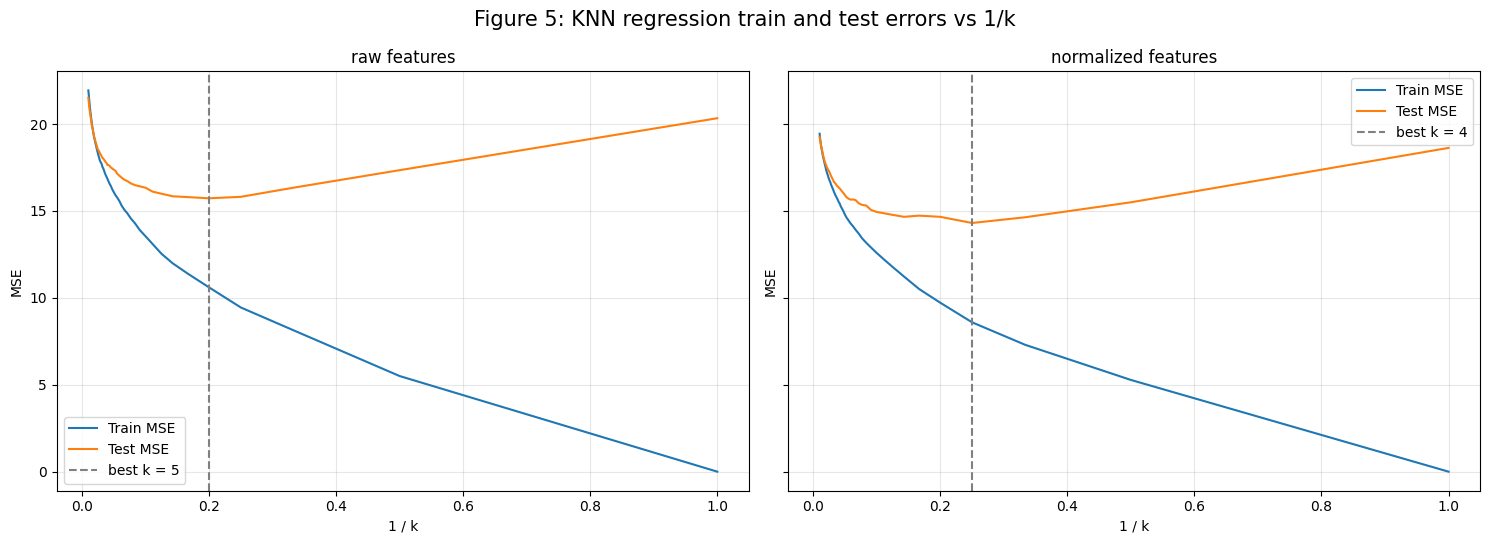

,best k,train MSE at best k,test MSE at best k
features,,,
raw,5,10.600769,15.726820
normalized,4,8.591433,14.305669


In [18]:
X_train_raw, y_train = train_df[predictors].to_numpy(), train_df[response].to_numpy()
X_test_raw, y_test = test_df[predictors].to_numpy(), test_df[response].to_numpy()

scaler = StandardScaler().fit(X_train_raw)
feature_sets = {
    'raw': (X_train_raw, X_test_raw),
    'normalized': (scaler.transform(X_train_raw), scaler.transform(X_test_raw)),
}

ks = range(1, 101)
knn_errors = {}
for name, (X_tr, X_te) in feature_sets.items():
    train_mse, test_mse = [], []
    for k in ks:
        model = KNeighborsRegressor(n_neighbors=k).fit(X_tr, y_train)
        train_mse.append(mean_squared_error(y_train, model.predict(X_tr)))
        test_mse.append(mean_squared_error(y_test, model.predict(X_te)))
    knn_errors[name] = (np.array(train_mse), np.array(test_mse))

inv_k = 1 / np.array(ks)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, (name, (train_mse, test_mse)) in zip(axes, knn_errors.items()):
    ax.plot(inv_k, train_mse, label='Train MSE')
    ax.plot(inv_k, test_mse, label='Test MSE')
    best = np.argmin(test_mse)
    ax.axvline(inv_k[best], color='gray', ls='--', label=f'best k = {list(ks)[best]}')
    ax.set_xlabel('1 / k')
    ax.set_ylabel('MSE')
    ax.set_title(f'{name} features')
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle('Figure 5: KNN regression train and test errors vs 1/k', fontsize=15)
fig.tight_layout()
plt.show()

knn_summary = pd.DataFrame([{
    'features': name,
    'best k': list(ks)[np.argmin(test_mse)],
    'train MSE at best k': train_mse[np.argmin(test_mse)],
    'test MSE at best k': test_mse.min(),
} for name, (train_mse, test_mse) in knn_errors.items()]).set_index('features')
knn_summary

**Answer 1(i):**

| Features | Best k | Train MSE at best k | Test MSE at best k |
|---|---|---|---|
| Raw | 5 | 10.601 | 15.727 |
| Normalized | 4 | 8.591 | 14.306 |

**Normalized features with k = 4 give the best fit** (test MSE 14.306), about 9% better than the best raw-feature model. Normalization matters because Euclidean distance is dominated by whichever feature has the largest numeric spread: AP ranges over about 40 millibar and RH over 75 percentage points, so on raw features the neighbor search is driven by RH and V and effectively underweights AT, the most informative predictor. Standardizing puts all four on the same footing.

Figure 5 shows the classic bias-variance picture in terms of 1/k, which measures flexibility. At the left (large k, inflexible) both errors are high because the model averages over too wide a neighborhood. Moving right, both fall to a minimum test error near 1/k ≈ 0.2-0.25, and past that the train MSE keeps falling to 0 at k = 1 (each point is its own neighbor) while the test MSE climbs again, which is overfitting.

## 1(j) Comparison of KNN regression and linear regression

In [19]:
best_knn = knn_summary['test MSE at best k'].idxmin()
comparison = pd.DataFrame({
    'train MSE': [mse_a[0], mse_b[0], knn_summary.loc[best_knn, 'train MSE at best k']],
    'test MSE': [mse_a[1], mse_b[1], knn_summary.loc[best_knn, 'test MSE at best k']],
}, index=['Linear: all predictors',
          'Linear: interactions + quadratics, pruned',
          f'KNN ({best_knn} features, k = {knn_summary.loc[best_knn, "best k"]})'])
comparison.round(3)

,train MSE,test MSE
Linear: all predictors,20.581,21.240
"Linear: interactions + quadratics, pruned",17.891,18.660
"KNN (normalized features, k = 4)",8.591,14.306


**Answer 1(j):** On the same 70/30 split:

| Model | Train MSE | Test MSE |
|---|---|---|
| Linear, all predictors | 20.581 | 21.240 |
| Linear, interactions + quadratics, pruned | 17.891 | 18.660 |
| KNN, normalized features, k = 4 | 8.591 | 14.306 |

**KNN regression wins.** Its test MSE of 14.306 beats the best linear model (18.660) by 23%, and beats the plain linear model by 33%. Analysis:

- **Why KNN does better here.** The conditions favour a flexible method, exactly as ISLR 2.4.1(a) predicts: n = 9568 observations over only p = 4 predictors, so neighborhoods are densely populated and local averaging is reliable. Parts 1(f) and 1(g) established real curvature and real interactions, and KNN captures those automatically without anyone specifying the functional form, whereas the linear models can only fit the specific terms written into them.
- **The cost is variance and interpretability.** KNN's train MSE (8.59) is far below its test MSE (14.31), a gap of 5.7, while the linear models sit within 0.8 of their train error. KNN is fitting some noise, and it produces no coefficients, no p-values and no statement like "one extra °C costs 1.98 MW". The linear model in 1(d) answers the physical question; KNN only predicts.
- **Other practical differences.** KNN needs the features normalized to work well, stores the whole training set and searches it at prediction time, and cannot extrapolate beyond the range of the training data, whereas the fitted linear model is a handful of numbers.

**Conclusion:** if the goal is pure predictive accuracy on data like this, use KNN with normalized features and k = 4. If the goal is understanding how the ambient variables drive output, the pruned linear model is the better tool and gives up a moderate amount of accuracy for it.

# 2. ISLR 2.4.1

For each part, state whether a flexible statistical learning method would perform **better** or **worse** than an inflexible one, and why.

**(a) Sample size n is extremely large, number of predictors p is small.**  
**Better.** A large n lets a flexible method estimate many parameters without much variance, so it can capture the true shape of f while the variance penalty stays small. An inflexible method would be limited by its bias, which extra data cannot reduce.

**(b) Number of predictors p is extremely large, number of observations n is small.**  
**Worse.** With few observations spread over many dimensions, a flexible method has too much freedom and fits the noise, so its variance is large and it overfits. An inflexible method is more constrained and generalizes better here.

**(c) The relationship between the predictors and the response is highly non-linear.**  
**Better.** An inflexible method such as linear regression cannot represent a highly non-linear f, so it suffers large bias no matter how much data is available. A flexible method can follow the true shape and reduce that bias.

**(d) The variance of the error terms, σ² = Var(ε), is extremely high.**  
**Worse.** A flexible method follows the data closely, so with very noisy data it fits the noise rather than the signal, and its test error grows. The extra rigidity of an inflexible method smooths the noise out.

# 3. ISLR 2.4.7

The table below provides a training data set of six observations, three predictors, and one qualitative response. We wish to predict the response for X₁ = X₂ = X₃ = 0 using K-nearest neighbors.

| Obs. | X₁ | X₂ | X₃ | Y |
|---|---|---|---|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | −1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

**(a) Compute the Euclidean distance between each observation and the test point X₁ = X₂ = X₃ = 0.**

In [20]:
islr = pd.DataFrame({
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red'],
}, index=pd.RangeIndex(1, 7, name='Obs.'))

islr['distance'] = np.sqrt((islr[['X1', 'X2', 'X3']] ** 2).sum(axis=1))
islr.sort_values('distance').round(3)

,X1,X2,X3,Y,distance
Obs.,,,,,
5,-1,0,1,Green,1.414
6,1,1,1,Red,1.732
2,2,0,0,Red,2.000
4,0,1,2,Green,2.236
1,0,3,0,Red,3.000
3,0,1,3,Red,3.162


**Answer 3(a):** The distances to the test point are

| Obs. | Distance |
|---|---|
| 1 | 3.000 |
| 2 | 2.000 |
| 3 | √10 ≈ 3.162 |
| 4 | √5 ≈ 2.236 |
| 5 | √2 ≈ 1.414 |
| 6 | √3 ≈ 1.732 |

**(b) What is our prediction with K = 1? Why?**  
**Green.** The single nearest neighbor is observation 5, at distance √2 ≈ 1.414, and its response is Green, so with K = 1 the prediction is that neighbor's class.

**(c) What is our prediction with K = 3? Why?**  
**Red.** The three nearest neighbors are observations 5 (√2, Green), 6 (√3, Red) and 2 (2, Red). Two of the three are Red, so the majority vote gives Red, with estimated probability 2/3.

**(d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?**  
**Small.** A small K makes KNN flexible: the prediction depends on only a few nearby points, so the fitted boundary can bend sharply and follow a non-linear Bayes boundary. A large K averages over many points from a wide region, which smooths the boundary towards a nearly linear one and introduces bias.

## References

1. UCI Machine Learning Repository, Combined Cycle Power Plant Data Set: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant
2. statsmodels, ordinary least squares and formula API: https://www.statsmodels.org/stable/regression.html
3. statsmodels, outlier and influence measures: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html
4. scikit-learn, `KNeighborsRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
5. scikit-learn, generating polynomial features: https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features
6. James, Witten, Hastie, Tibshirani, *An Introduction to Statistical Learning*, Springer (Sections 2.4.1 and 2.4.7, and Chapter 3).